# Mass-Created or Automated Fake Accounts Analysis

In [1]:
# import imp modules 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib

from kneed import KneeLocator
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import IsolationForest

# Data Loading and Preparing 

In [2]:
df = pd.read_csv("Instagram_fake_profile_dataset.csv")

In [3]:
X = df.drop(columns = ["fake"])
X

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
0,1,0.270000,0,0.000000,0,53,0,0,32,1000,955
1,1,0.000000,2,0.000000,0,44,0,0,286,2740,533
2,1,0.100000,2,0.000000,0,0,0,1,13,159,98
3,1,0.000000,1,0.000000,0,82,0,0,679,414,651
4,1,0.000000,2,0.000000,0,0,0,1,6,151,126
...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0.258135,0,0.000000,0,0,0,1,7,1,217
4996,0,0.511986,1,0.000000,0,0,0,0,0,51,24
4997,0,0.473108,1,0.353231,0,0,0,0,0,20,0
4998,0,0.293326,1,0.000000,0,0,0,0,75,1314,5120


# EDA

## Pair Plots

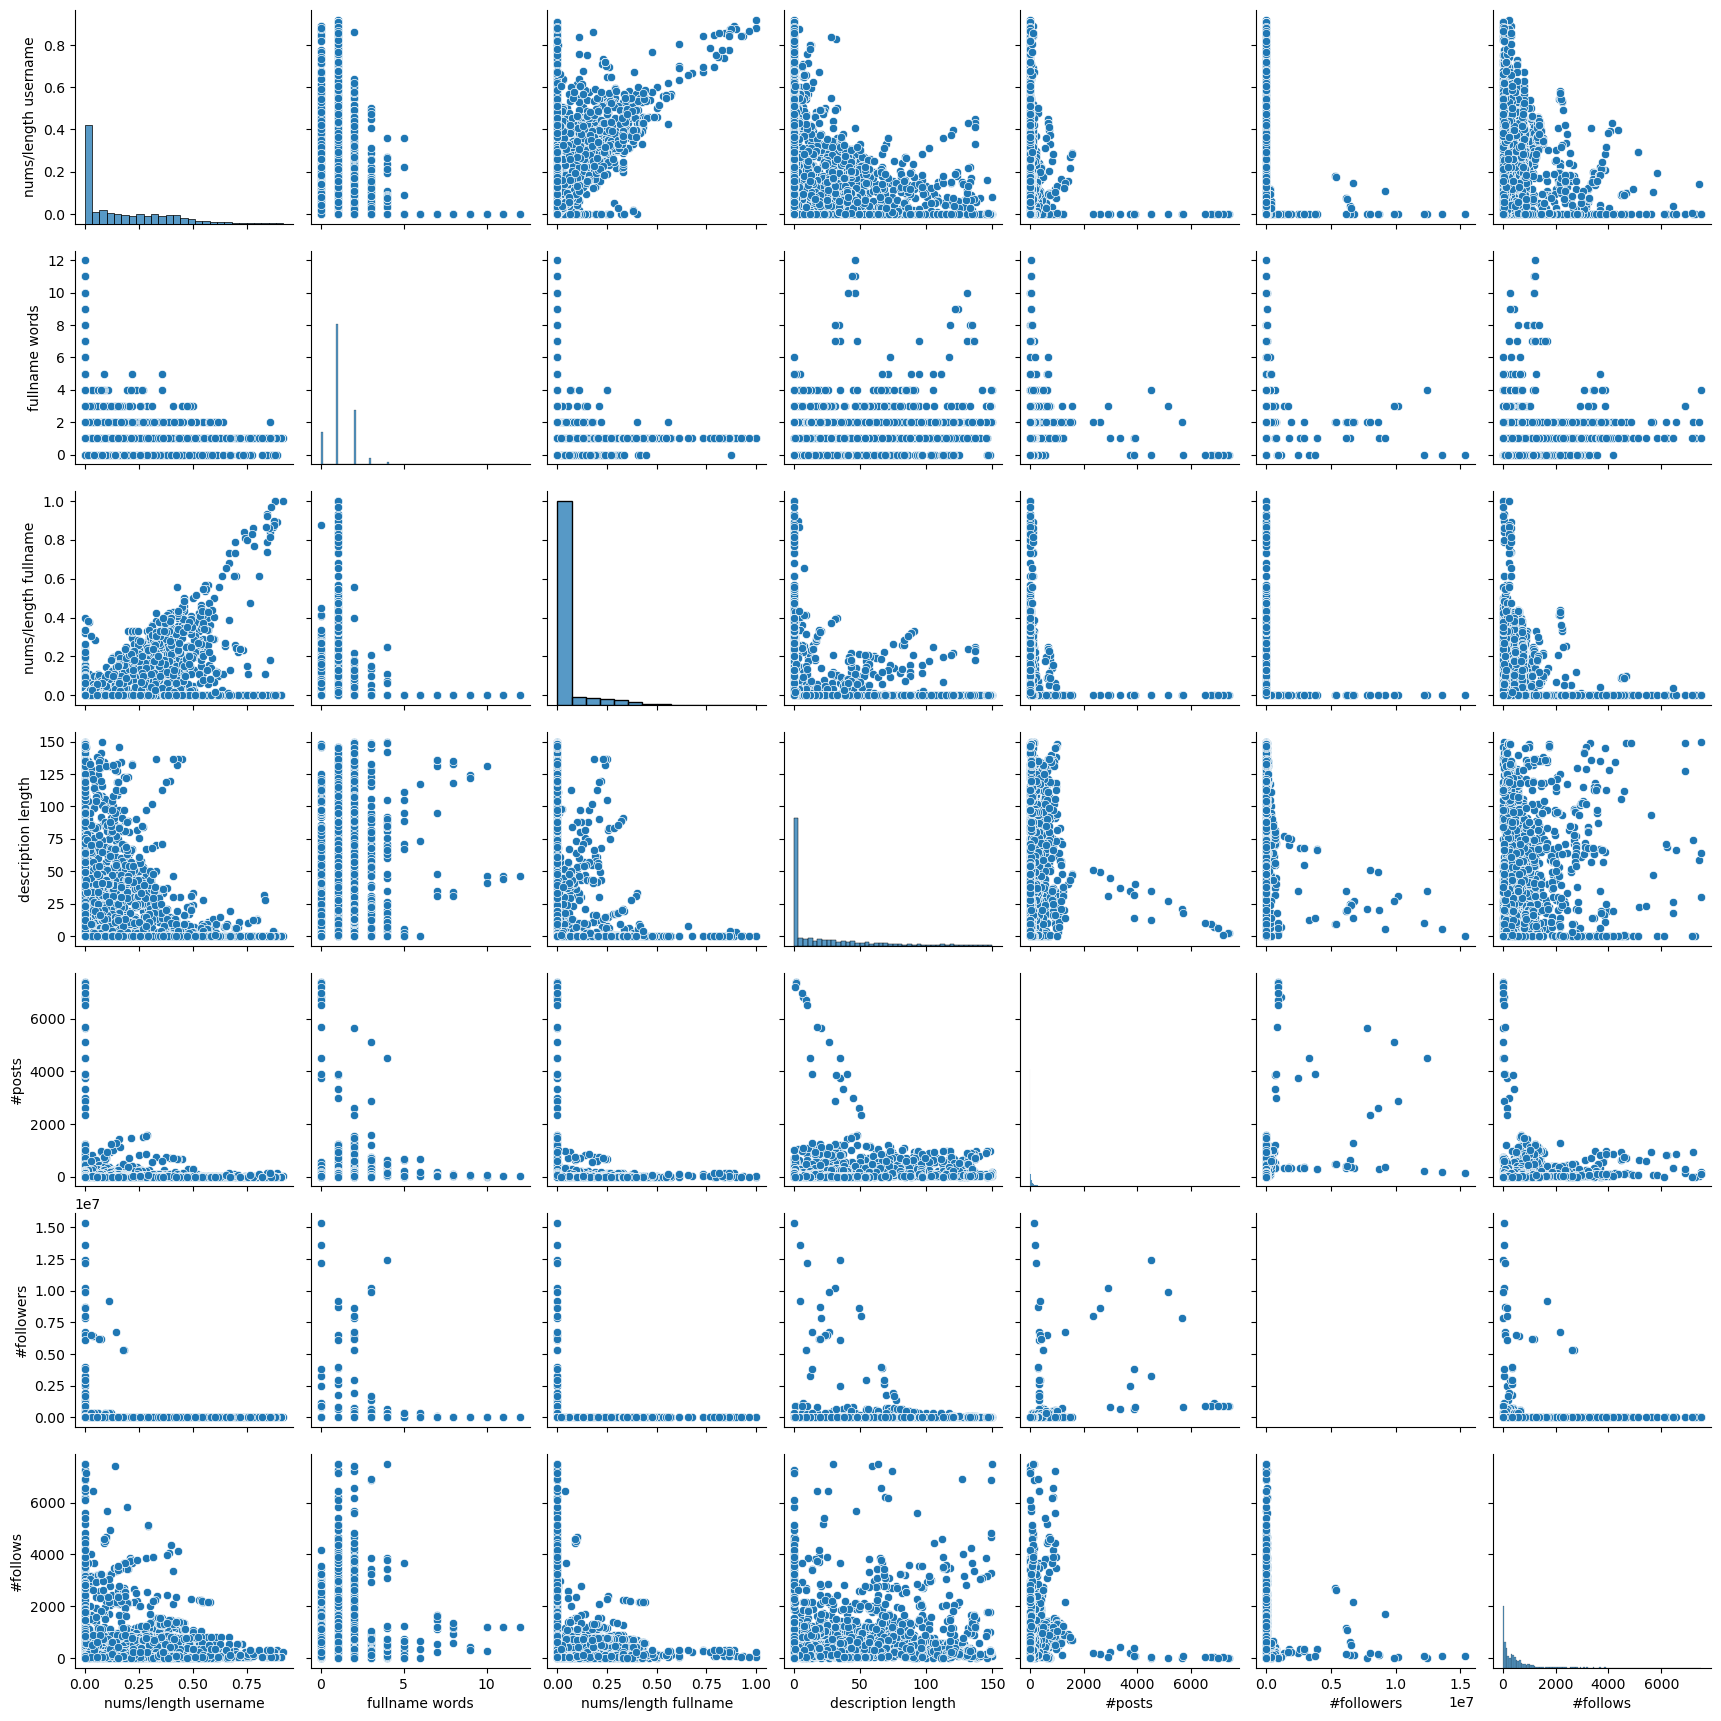

In [35]:
num_cols = ["nums/length username", "fullname words", "nums/length fullname", "description length", "#posts", "#followers", "#follows"]

sns.pairplot(df[num_cols])

## Heatmap 
- If |correlation| > 0.85–0.90, the features contain very similar information.
- Remove one of them to avoid distance distortion in clustering.
- Reason : Clustering algorithms use distance calculations, and redundant features double-count the same behavior.

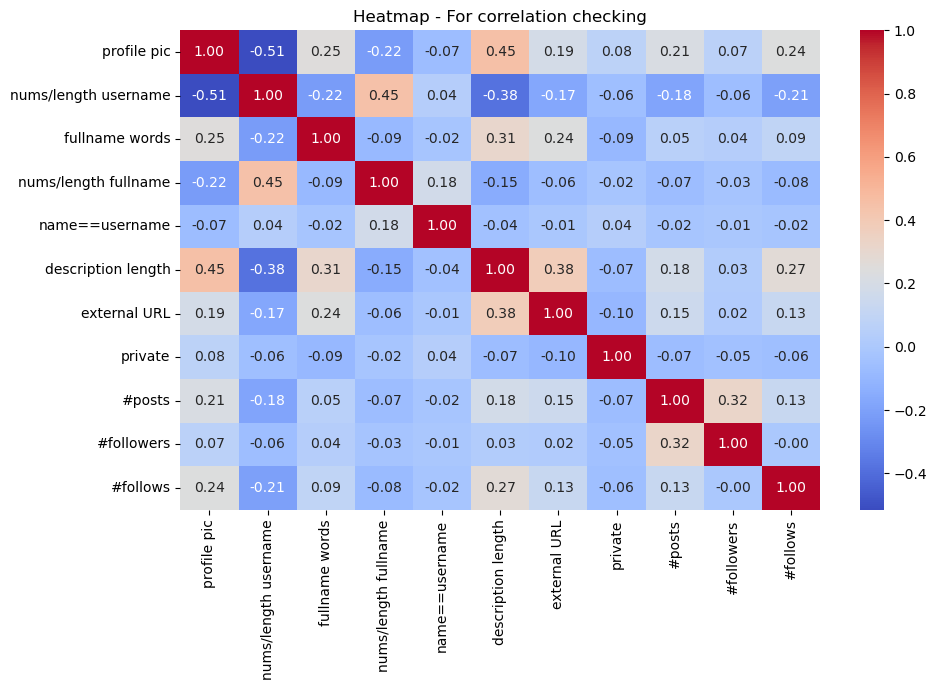

In [5]:
corr_matrix = X.corr()

plt.figure(figsize = (10, 7))
plt.title("Heatmap - For correlation checking")

sns.heatmap(
    corr_matrix, 
    fmt = ".2f",
    cmap = "coolwarm",
    annot = True
)

plt.tight_layout()

## Varience Check 
- Variance < 0.01 → consider removing the feature.
- Reason : Low-variance features contribute almost nothing to cluster separation.

In [6]:
X.var().sort_values()

name==username          7.543749e-03
nums/length fullname    1.128594e-02
nums/length username    3.792089e-02
external URL            4.714927e-02
private                 1.759423e-01
profile pic             2.404048e-01
fullname words          7.928747e-01
description length      1.104546e+03
#posts                  1.427365e+05
#follows                5.799281e+05
#followers              3.556630e+11
dtype: float64

## Skewness Cheking 
- if skewness is greater than 1 that case we have log transform over features.
- Recommended transformation : np.log1p(feature)

In [7]:
X.skew().sort_values(ascending = False)

#followers              16.429362
#posts                  12.495264
name==username          11.343007
nums/length fullname     4.158731
external URL             4.150158
#follows                 4.040513
fullname words           3.152433
description length       1.832036
private                  1.298395
nums/length username     1.127623
profile pic             -0.400722
dtype: float64

## Feature Scale Inspection
- we can apply through df.describe()
- Purpose : Check if some features have much larger ranges than others.
- Solution : Apply StandardScaler or RobustScaler before clustering.

In [8]:
X.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,0.598200,0.166175,1.212800,0.036068,0.007600,20.997200,0.049600,0.227800,103.331400,5.124435e+04,481.381800
std,0.490311,0.194733,0.890435,0.106235,0.086855,33.234706,0.217139,0.419455,377.804886,5.963749e+05,761.530132
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+01,58.000000
50%,1.000000,0.089193,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,1.450000e+02,242.000000
75%,1.000000,0.300410,2.000000,0.000000,0.000000,31.250000,0.000000,0.000000,81.000000,6.960000e+02,591.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000


# Feature Engineering - Feature Adjustment 

## Log Transformation - High Skwed

In [4]:
X["#followers"] = np.log1p(X["#followers"])
X["#posts"] = np.log1p(X["#posts"])
X["#follows"] = np.log1p(X["#follows"])

## Standardize data

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA 

### 2D PCA visualization

In [6]:
pca_2d = PCA(n_components = 2, random_state = 40)
X_pca_2d = pca_2d.fit_transform(X)
pca_2d.explained_variance_ratio_

array([0.98972654, 0.0068403 ])

Text(0, 0.5, 'PCA 2')

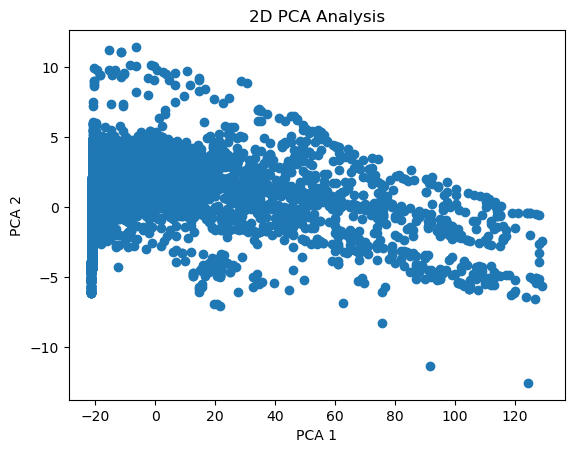

In [7]:
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o')

plt.title("2D PCA Analysis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

### 3D PCA Visualization

In [8]:
pca_3d = PCA(n_components = 3, random_state = 42)
X_pca_3d = pca_3d.fit_transform(X)
pca_3d.explained_variance_ratio_

array([0.98972654, 0.0068403 , 0.00153257])

Text(0.5, 0.92, '3D Projection')

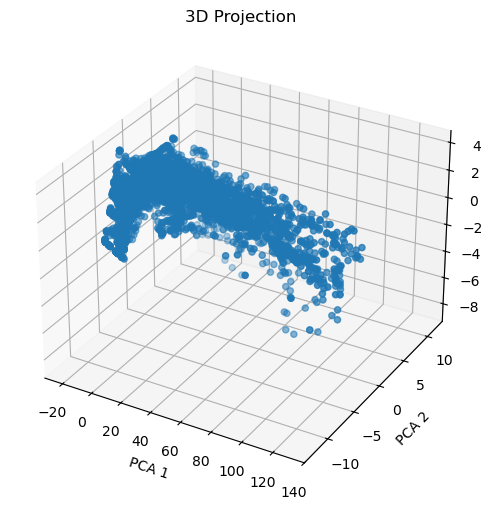

In [9]:
# Plot
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Projection")

# Forming Clusturing 

## 1) KMeans Clusturing
- Best K for this algorithm = 3

### Elbow Method

In [3]:
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_pca_3d)
    wcss.append(kmeans.inertia_)

In [11]:
# Find the elbow point with the kneelocator
knee = KneeLocator(range(2, 11), wcss, curve = "convex", direction = "decreasing")
knee.knee

np.int64(4)

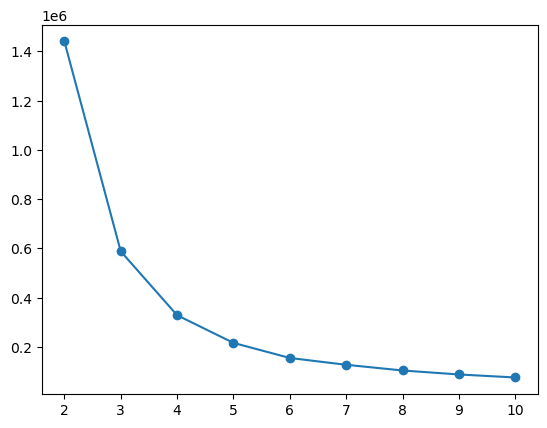

In [12]:
# Plot the graph ans find the elbow points 
plt.plot(range(2, 11), wcss, marker = 'o')

In [13]:
# Test the result 
Kmeans = KMeans(n_clusters = 3, random_state = 42)
labels = Kmeans.fit_predict(X_pca_3d)

Text(0, 0.5, 'PCA 2')

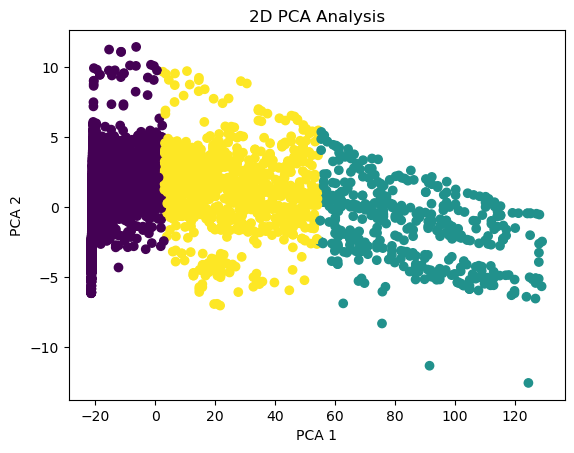

In [14]:
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = labels)

plt.title("2D PCA Analysis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

### Silhouette Score Method

In [20]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca_3d)
    score = silhouette_score(X_pca_3d, labels)
    scores.append(score)

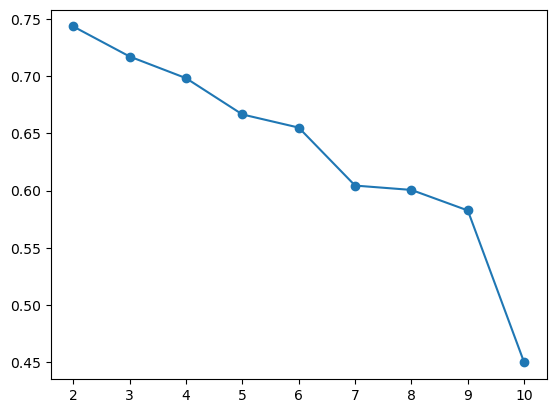

In [21]:
plt.plot(range(2, 11), scores, marker = 'o')

### Final K Determination using combined both graphs Elbow and Silhoutte_score

Text(0, 0.5, 'Silhouette_Score')

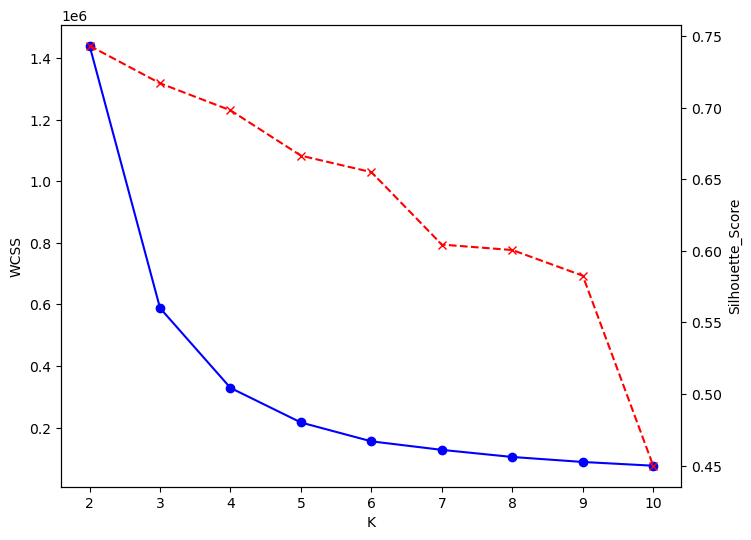

In [22]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(k_range, wcss, marker = 'o', color = "Blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores, marker = "x", color = "red", linestyle = "--")
ax2.set_ylabel("Silhouette_Score")

## 2) Hierarchical Clusturing

### Draw the Dendrogram 
- With the help of Dendrogram k is 3

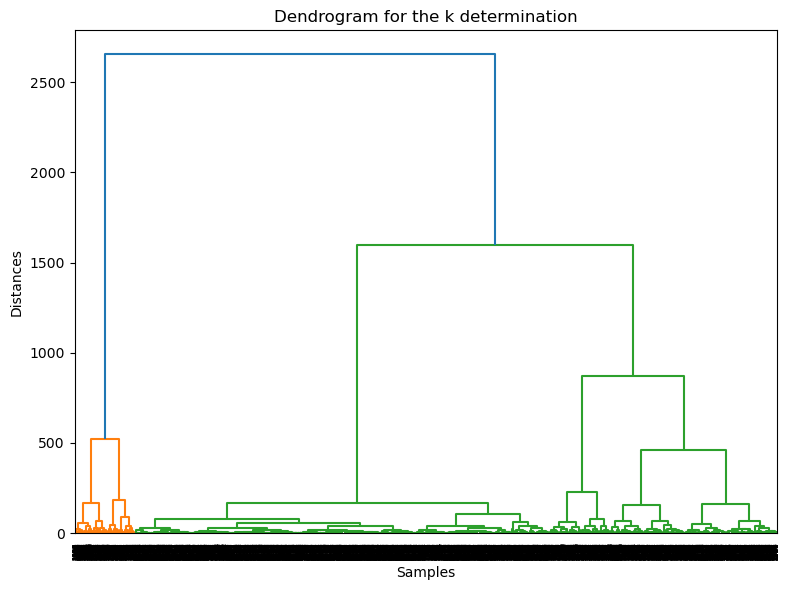

In [23]:
# Necessary modules for the dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram

# Create the Linkage 
z = linkage(X_pca_3d, method = "ward")

plt.figure(figsize = (8, 6))
plt.title("Dendrogram for the k determination")

dendrogram(z)

plt.xlabel("Samples")
plt.ylabel("Distances")

plt.tight_layout()

In [8]:
# Apply the agglormerative clustering 
model = AgglomerativeClustering(n_clusters = 3)
labels = model.fit_predict(X_pca_3d)

Text(0, 0.5, 'PCA 2')

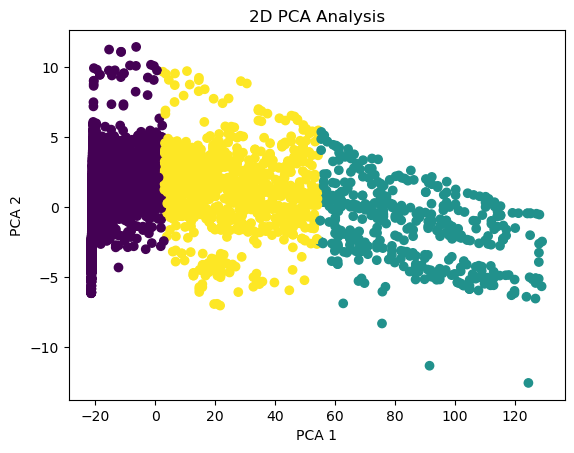

In [15]:
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = labels)

plt.title("2D PCA Analysis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

## 3) IsolationForest 
- Detect only very suspecious points.

In [16]:
iso_model = IsolationForest(
    n_estimators = 101, 
    random_state = 42
)

iso_labels = iso_model.fit_predict(X_pca_3d)

In [17]:
print("Very Suspecious DataPoint Lenght: ", len(iso_labels[iso_labels == -1]))

Very Suspecious DataPoint Lenght:  987


Text(0, 0.5, 'PCA 2')

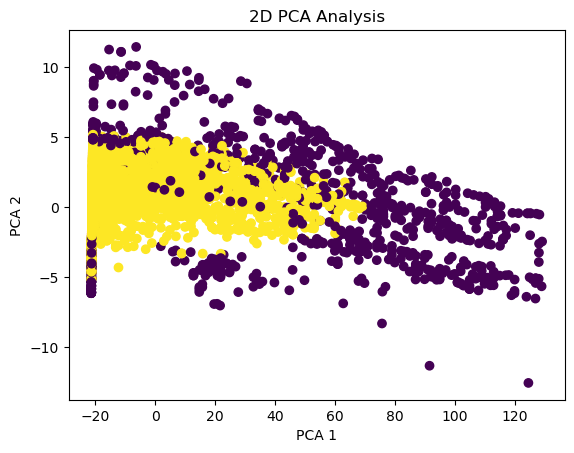

In [18]:
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = iso_labels)

plt.title("2D PCA Analysis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

## Final Plot for the all algorithm Cluster forming 

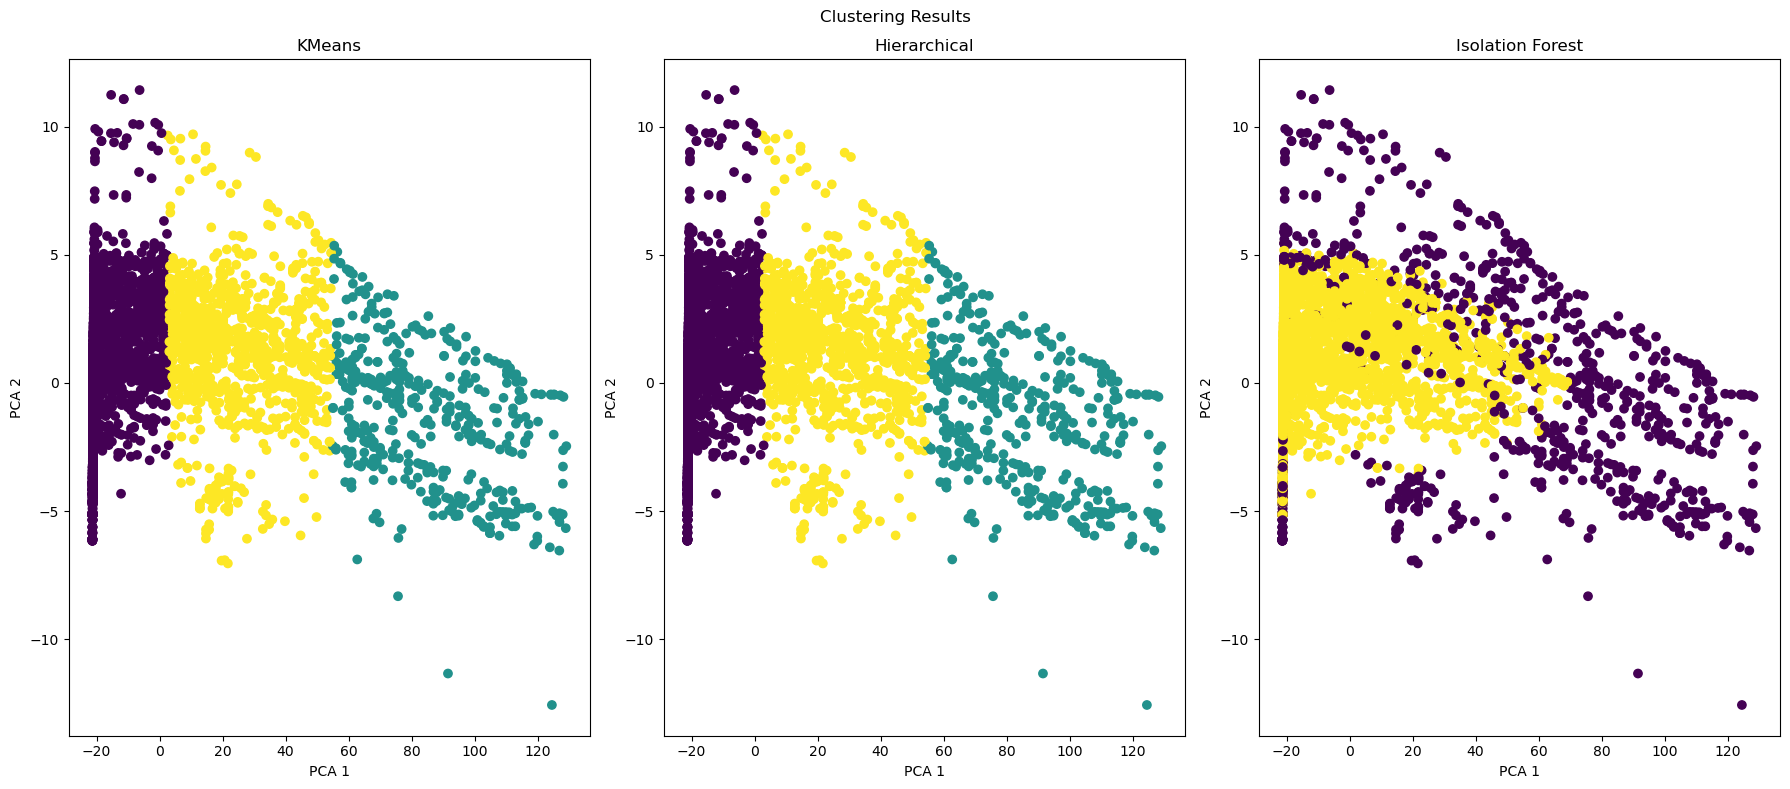

In [19]:
fig, axes = plt.subplots(1, 3, figsize = (18, 8))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = labels)
axes[0].set_title("KMeans")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = labels)
axes[1].set_title("Hierarchical")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], marker = 'o', c = iso_labels)
axes[2].set_title("Isolation Forest")
axes[2].set_xlabel("PCA 1")
axes[2].set_ylabel("PCA 2")

fig.suptitle("Clustering Results")
fig.tight_layout()

# Profiling of the Clusters 

In [20]:
X["Clusters"] = labels
X["Anomalies"] = iso_labels

In [21]:
print(len(X.query("Clusters == 0")))
print(len(X.query("Clusters == 0 and Anomalies == -1"))) # 2 => 264 1=> 394 0=> 329 

3498
312


In [22]:
print(X.groupby("Clusters").mean())

          profile pic  nums/length username  fullname words  \
Clusters                                                      
0            0.447684              0.216848        1.053173   
1            0.981818              0.036345        1.815909   
2            0.935028              0.053058        1.488701   

          nums/length fullname  name==username  description length  \
Clusters                                                             
0                     0.047305        0.010006            2.997999   
1                     0.012237        0.002273          106.970455   
2                     0.008930        0.001883           44.662900   

          external URL   private    #posts  #followers  #follows  Anomalies  
Clusters                                                                     
0             0.009148  0.241852  1.791568    4.358625  4.739234   0.821612  
1             0.270455  0.159091  4.649577    7.628461  5.995913  -0.831818  
2             0.09133

## Cluster Interpretation and Behavioral Analysis

After applying clustering algorithms (KMeans and Hierarchical Clustering), the users were grouped into **three distinct behavioral clusters** based on their profile attributes, activity patterns, and metadata features.  
The clusters were interpreted by analyzing the **average feature values within each cluster**.

---

### Cluster 0 – Moderate Active Users

Users in this cluster appear to have **moderate engagement and relatively complete profiles**.

Key observations:
- Majority of users have a **profile picture**.
- Username numeric ratio is **low**, indicating normal-looking usernames.
- Descriptions exist but are **moderate in length**.
- Posting activity, followers, and following counts are **moderate**.
- Only a small proportion includes **external links**.

Interpretation:

These accounts likely represent **regular platform users with moderate activity levels**.  
They maintain reasonably complete profiles but do not show extremely high engagement or promotional behavior.

---

### Cluster 1 – Highly Active Users

This cluster represents users with **high activity and well-developed profiles**.

Key observations:
- Nearly all accounts have **profile pictures**.
- Usernames contain **very few numeric characters**, indicating authentic naming patterns.
- Descriptions are **significantly longer**, suggesting detailed profile information.
- Higher probability of having **external URLs** in profiles.
- Highest averages for **posts, followers, and engagement-related features**.

Interpretation:

These users likely correspond to **highly active accounts**, such as content creators, influencers, or business profiles.  
Their profiles are well-maintained and contain richer information compared to other clusters.

---

### Cluster 2 – Suspicious Users

This cluster exhibits several characteristics commonly associated with **low-quality or potentially fake accounts**.

Key observations:
- A large proportion of accounts **lack profile pictures**.
- Usernames contain **high numeric ratios**, often seen in automatically generated usernames.
- Profiles typically have **almost no description text**.
- Very few accounts contain **external links**.
- Posting activity, follower counts, and engagement levels are **significantly lower** than other clusters.

Interpretation:

These accounts display multiple **suspicious behavioral patterns**, including incomplete profiles, minimal activity, and irregular username structures.  
Such characteristics are commonly observed in **mass-created or automated fake accounts**, making this cluster the most likely candidate for suspicious user detection.

---

### Summary

The clustering analysis reveals **three distinct user behavior groups**:

| Cluster | Interpretation |
|-------|----------------|
| Cluster 0 | Moderate Active Users |
| Cluster 1 | Highly Active Users |
| Cluster 2 | Suspicious Users |

This behavioral segmentation provides valuable insight into different user types on the platform and helps identify clusters that exhibit **potentially anomalous or suspicious account characteristics**.

# Dump (Save) Models 

In [12]:
joblib.dump(model, "Agglomerative_model.pkl")
joblib.dump(iso_model, "iso_forest.pkl")
joblib.dump(Kmeans, "KMeans.pkl")

['KMeans.pkl']

In [14]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca_3d, "pca.pkl")

['pca.pkl']

In [18]:
import sklearn
print(sklearn.__version__)

1.6.1


In [19]:
import sys
print(sys.executable)

C:\Users\jashs\anaconda3\python.exe


In [23]:
X.to_csv("clustered_accounts.csv", index=False)

In [10]:
df = pd.read_csv("clustered_accounts.csv").copy()
df

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,Clusters,Anomalies
0,1,0.270000,0,0.000000,0,53,0,0,3.496508,6.908755,6.862758,2,1
1,1,0.000000,2,0.000000,0,44,0,0,5.659482,7.916078,6.280396,2,1
2,1,0.100000,2,0.000000,0,0,0,1,2.639057,5.075174,4.595120,0,1
3,1,0.000000,1,0.000000,0,82,0,0,6.522093,6.028279,6.480045,1,1
4,1,0.000000,2,0.000000,0,0,0,1,1.945910,5.023881,4.844187,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0.258135,0,0.000000,0,0,0,1,2.079442,0.693147,5.384495,0,-1
4996,0,0.511986,1,0.000000,0,0,0,0,0.000000,3.951244,3.218876,0,1
4997,0,0.473108,1,0.353231,0,0,0,0,0.000000,3.044522,0.000000,0,-1
4998,0,0.293326,1,0.000000,0,0,0,0,4.330733,7.181592,8.541105,0,-1
